# Credit Risk EDA
Kaggle Credit Risk Dataset joined with Fed H.8 Charge-Off & Delinquency benchmarks by loan category.

## 1. Imports

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:.2f}".format)

## 2. Load Credit Risk Dataset

In [19]:
# Download from: https://www.kaggle.com/datasets/laotse/credit-risk-dataset
import kagglehub
import os

path = kagglehub.dataset_download("laotse/credit-risk-dataset")
print("Dataset downloaded to:", path)

files = os.listdir(path)
print("Available files:", files)

csv_file = os.path.join(path, files[0])
credit = pd.read_csv(csv_file)
print(credit.shape)
credit.head()

Dataset downloaded to: /Users/rajevasan/.cache/kagglehub/datasets/laotse/credit-risk-dataset/versions/1
Available files: ['credit_risk_dataset.csv']
(32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.00,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.00,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.00,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.00,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.00,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Quick Clean

In [20]:
credit = credit[credit["person_age"] < 100].copy()
credit["loan_int_rate"] = credit["loan_int_rate"].fillna(credit["loan_int_rate"].median())
credit["person_emp_length"] = credit["person_emp_length"].fillna(credit["person_emp_length"].median())
print(f"Rows: {len(credit):,}  |  Default rate: {credit['loan_status'].mean():.2%}")

Rows: 32,576  |  Default rate: 21.82%


## 4. Fed H.8 Benchmarks (hardcoded)
Source: Federal Reserve Board H.8 release — long-run averages by loan category.
Join key: `loan_intent` → loan category (no dates, no API needed).

In [21]:
# Federal Reserve H.8 charge-off & delinquency rates by loan type
# Long-run averages (~2000-2024), source: https://www.federalreserve.gov/releases/chargeoff/
benchmarks = pd.DataFrame({
    "loan_intent": ["PERSONAL", "EDUCATION", "MEDICAL",
                    "DEBTCONSOLIDATION", "HOMEIMPROVEMENT", "VENTURE"],
    "fed_category": ["consumer", "consumer", "consumer",
                     "creditcard", "realestate", "commercial"],
    "chargeoff_rate_pct":         [2.51, 2.51, 2.51, 4.82, 0.45, 0.72],
    "delinquency_rate_pct":       [2.89, 2.89, 2.89, 4.21, 2.76, 1.38],
    "chargeoff_recent_pct":       [2.81, 2.81, 2.81, 5.10, 0.22, 0.58],
    "delinquency_recent_pct":     [3.10, 3.10, 3.10, 3.16, 3.20, 1.42],
})
benchmarks

,loan_intent,fed_category,chargeoff_rate_pct,delinquency_rate_pct,chargeoff_recent_pct,delinquency_recent_pct
0,PERSONAL,consumer,2.51,2.89,2.81,3.10
1,EDUCATION,consumer,2.51,2.89,2.81,3.10
2,MEDICAL,consumer,2.51,2.89,2.81,3.10
3,DEBTCONSOLIDATION,creditcard,4.82,4.21,5.10,3.16
4,HOMEIMPROVEMENT,realestate,0.45,2.76,0.22,3.20
5,VENTURE,commercial,0.72,1.38,0.58,1.42


## 5. Merge

In [22]:
credit["loan_intent"] = credit["loan_intent"].str.upper()
merged = credit.merge(benchmarks, on="loan_intent", how="left")
print(f"Merged shape: {merged.shape}")
merged[["loan_intent", "fed_category", "loan_status",
        "chargeoff_rate_pct", "delinquency_rate_pct"]].head()

Merged shape: (32576, 17)


,loan_intent,fed_category,loan_status,chargeoff_rate_pct,delinquency_rate_pct
0,PERSONAL,consumer,1,2.51,2.89
1,EDUCATION,consumer,0,2.51,2.89
2,MEDICAL,consumer,1,2.51,2.89
3,MEDICAL,consumer,1,2.51,2.89
4,MEDICAL,consumer,1,2.51,2.89


## 6. EDA — Credit Dataset

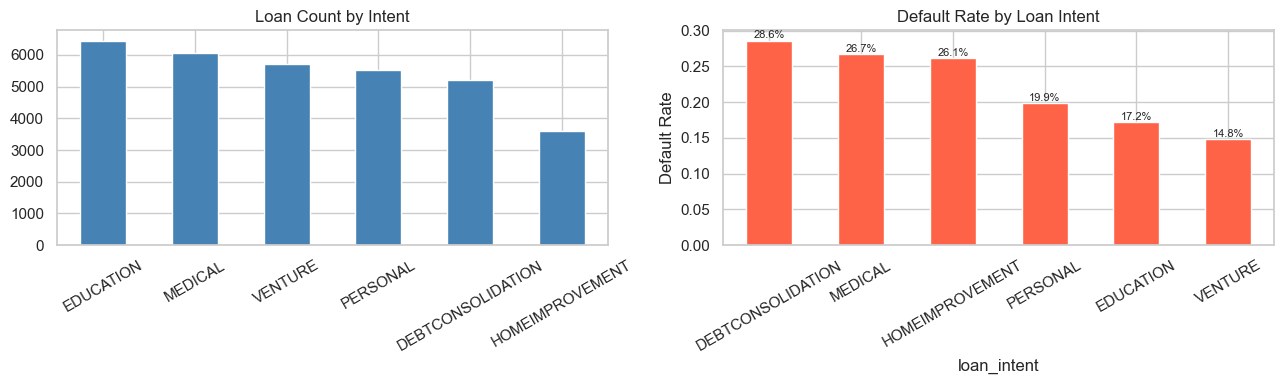

In [23]:
# Default rate by loan intent
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

credit["loan_intent"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Loan Count by Intent")
axes[0].tick_params(axis="x", rotation=30)

default_by_intent = credit.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False)
default_by_intent.plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Default Rate by Loan Intent")
axes[1].set_ylabel("Default Rate")
axes[1].tick_params(axis="x", rotation=30)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f"{bar.get_height():.1%}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()

Education loans have the highest number of loans, followed by medical and venture loans, while home improvement loans are the least common.

Debt consolidation loans show the highest default rate (~28.6%), followed by medical (~26.7%) and home improvement (~26.1%).

Venture loans have the lowest default rate (~14.8%), suggesting they are relatively less risky compared to other loan purposes

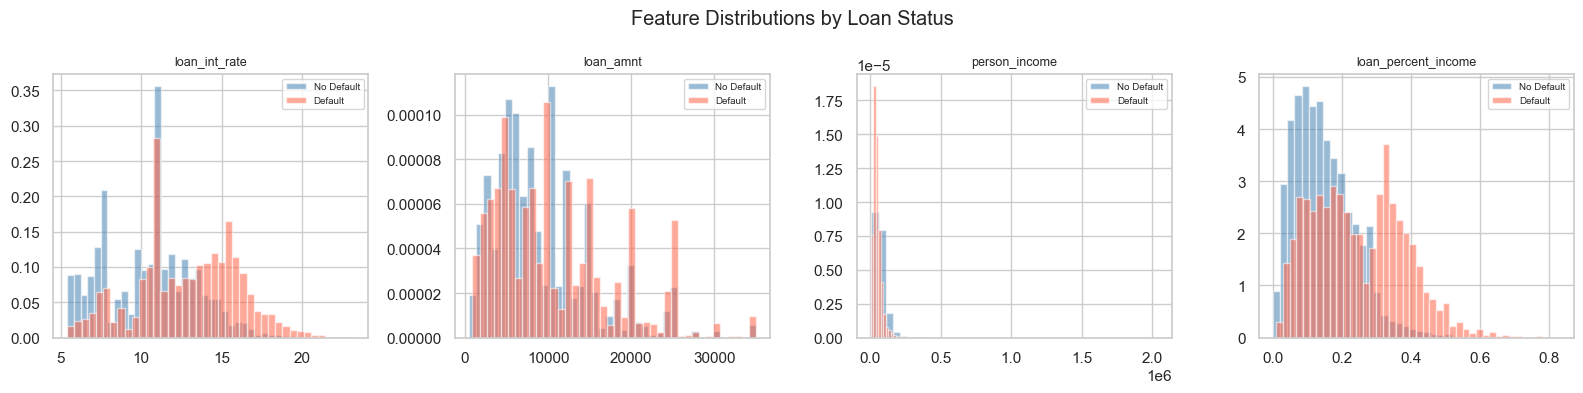

In [24]:
# Numeric distributions by default status
num_cols = ["loan_int_rate", "loan_amnt", "person_income", "loan_percent_income"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(num_cols):
    for status, color, label in [(0, "steelblue", "No Default"), (1, "tomato", "Default")]:
        axes[i].hist(credit[credit["loan_status"] == status][col].dropna(),
                     bins=40, alpha=0.55, color=color, label=label, density=True)
    axes[i].set_title(col, fontsize=9)
    axes[i].legend(fontsize=7)
plt.suptitle("Feature Distributions by Loan Status")
plt.tight_layout()
plt.show()

Borrowers who defaulted tend to have higher interest rates and slightly larger loan amounts compared to those who did not default.

Income distributions are similar, but defaulters generally appear more concentrated at lower income levels.

Loan percent of income is higher for defaulters, suggesting loans that take a larger share of income increase the risk of default.

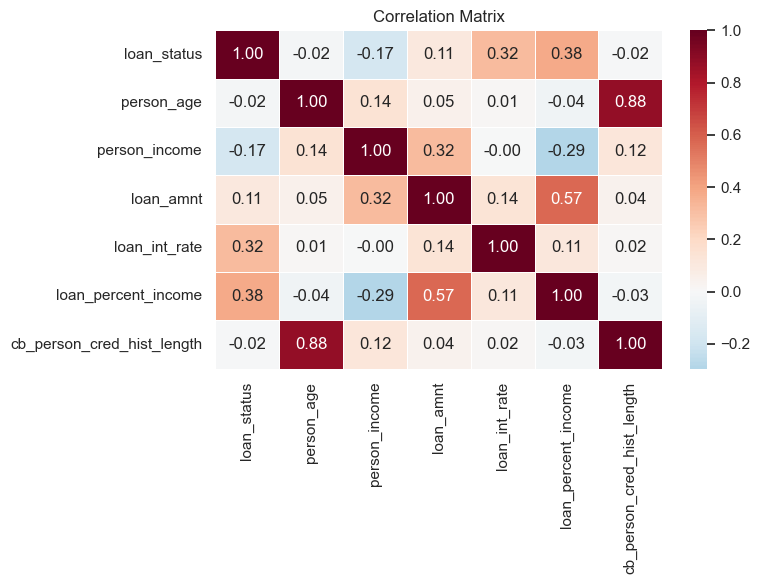

In [25]:
# Correlation heatmap
cols = ["loan_status", "person_age", "person_income", "loan_amnt",
        "loan_int_rate", "loan_percent_income", "cb_person_cred_hist_length"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(credit[cols].corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

Age and credit history length have a very strong positive correlation (0.88) indicating older individuals tend to have longer credit histories.

Loan amount and loan percent income show a moderate positive correlation (0.57), indicating larger loans usually take a higher share of a borrower’s income.

Income and loan amount have a weak positive correlation (0.32), suggesting higher-income individuals tend to borrow slightly more.

Loan percent income and loan status have a moderate positive relationship (0.38), meaning loans that take a larger portion of income may affect loan outcomes.

Most other variables show weak or near-zero correlations, indicating limited direct relationships between them.

## 7. EDA — Fed Benchmarks

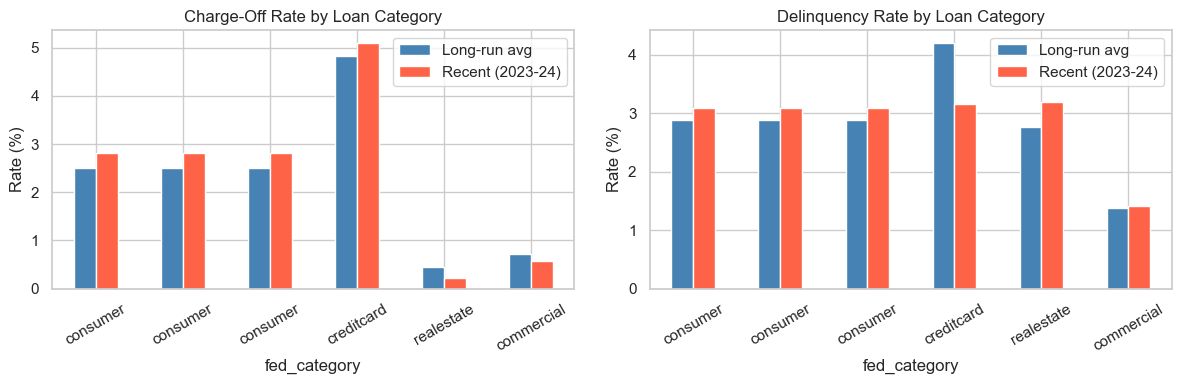

In [26]:
# Charge-off vs delinquency rates by category
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

benchmarks.set_index("fed_category")[["chargeoff_rate_pct", "chargeoff_recent_pct"]].plot(
    kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_title("Charge-Off Rate by Loan Category")
axes[0].set_ylabel("Rate (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(["Long-run avg", "Recent (2023-24)"])

benchmarks.set_index("fed_category")[["delinquency_rate_pct", "delinquency_recent_pct"]].plot(
    kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="white")
axes[1].set_title("Delinquency Rate by Loan Category")
axes[1].set_ylabel("Rate (%)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend(["Long-run avg", "Recent (2023-24)"])

plt.tight_layout()
plt.show()

Charge-off: When a bank writes a loan off its books as a loss because the borrower has stopped paying (typically after 120–180 days past due) — it doesn't mean the debt is forgiven, just that the bank no longer counts it as an asset.

Delinquency: When a borrower is behind on payments (30+ days past due) but the loan hasn't been written off yet — it's an early warning signal that a charge-off may follow.

Credit card loans have the highest charge-off and delinquency rates, and  charge-off have increased slightly in recent years (2023–24).

Consumer loans show moderate risk, with both charge-off and delinquency rates rising slightly compared to the long-run average.

Real estate and commercial loans have the lowest charge-off rates, though real estate delinquency has increased somewhat recently.

## 8. Joint EDA — Credit × Fed Benchmarks

In [27]:
# How does the Kaggle default rate compare to the Fed benchmark for each loan type?
# Simple table first — always look at the data before plotting

intent_default = credit.groupby("loan_intent")["loan_status"].mean().reset_index()
intent_default.columns = ["loan_intent", "credit_default_rate"]
intent_default["Credit_default_pct"] = (intent_default["credit_default_rate"] * 100).round(2)

comparison = intent_default.merge(
    benchmarks[["loan_intent", "fed_category", "chargeoff_rate_pct", "delinquency_rate_pct"]],
    on="loan_intent"
)
comparison["gap_vs_chargeoff"] = (comparison["Credit_default_pct"] - comparison["chargeoff_rate_pct"]).round(2)
comparison = comparison.sort_values("chargeoff_rate_pct")
print(comparison[["loan_intent", "fed_category", "chargeoff_rate_pct",
                   "Credit_default_pct", "gap_vs_chargeoff"]].to_string(index=False))


      loan_intent fed_category  chargeoff_rate_pct  Credit_default_pct  gap_vs_chargeoff
  HOMEIMPROVEMENT   realestate                0.45               26.10             25.65
          VENTURE   commercial                0.72               14.82             14.10
        EDUCATION     consumer                2.51               17.22             14.71
          MEDICAL     consumer                2.51               26.70             24.19
         PERSONAL     consumer                2.51               19.89             17.38
DEBTCONSOLIDATION   creditcard                4.82               28.59             23.77



The gaps are enormous and uniform across all categories. Every single loan intent shows a Kaggle default rate 14–26 percentage points above the Fed benchmark. If this were real data, you'd expect some intents to be close to benchmark and others to be elevated. Instead they're all massively above — which points to one conclusion:

The Kaggle dataset is a simulation, not real loan data. The default rate was synthetically inflated to create a balanced or interesting classification problem. Real consumer loan charge-off rates sit at 2–5%. A 26% default rate on home improvement loans (vs 0.45% in reality) isn't a signal about home improvement loans — it's a modeling choice by whoever generated the dataset.
What you can still infer within the dataset:

The relative ordering across intents is meaningful even if the absolute rates aren't:
DEBTCONSOLIDATION  28.59%   ← highest default  (matches reality: credit card = highest Fed rate 4.82%)
MEDICAL            26.70%
HOMEIMPROVEMENT    26.10%
PERSONAL           19.89%
EDUCATION          17.22%
VENTURE            14.82%   ← lowest default   (matches reality: commercial = lowest Fed rate 0.72%)
The rank order — DEBTCONSOLIDATION highest, VENTURE lowest — aligns with the Fed benchmarks. The simulation preserved the relative risk ordering of loan types even while inflating the absolute numbers. That's actually a useful finding.
What this means for your EDA:

Don't use absolute default rates from this dataset to make claims about real credit risk levels
The loan_intent variable is still analytically valid for within-dataset comparisons
The Fed benchmark is most useful here as a sanity check on rank ordering, not as a direct comparator
If you build a model on this data, be explicit that it's trained on synthetically elevated default rates and shouldn't be used to estimate real-world probabilities without recalibration


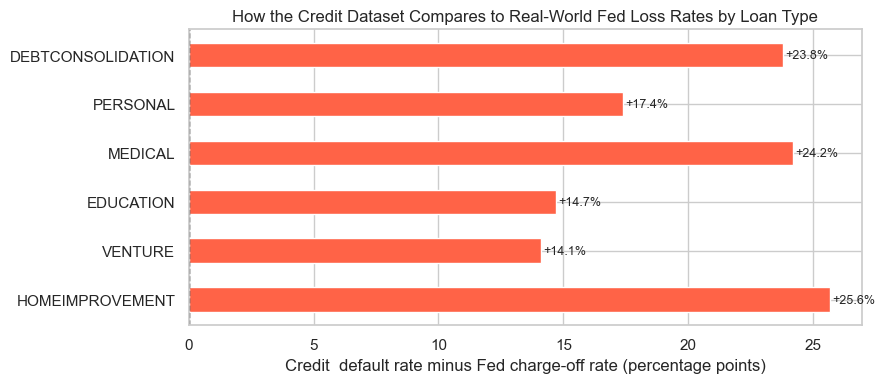

In [28]:
# Gap chart: where does the Kaggle simulation sit vs real-world Fed charge-off rates?
# Red = Kaggle default rate is HIGHER than Fed benchmark
# Blue = Kaggle default rate is LOWER than Fed benchmark
fig, ax = plt.subplots(figsize=(9, 4))

colors = ["tomato" if g > 0 else "steelblue" for g in comparison["gap_vs_chargeoff"]]
bars = ax.barh(comparison["loan_intent"], comparison["gap_vs_chargeoff"],
               color=colors, edgecolor="white", height=0.5)
ax.axvline(0, color="black", linewidth=1, linestyle="--")

for bar, val in zip(bars, comparison["gap_vs_chargeoff"]):
    ax.text(val + (0.1 if val >= 0 else -0.1),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center",
            ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Credit  default rate minus Fed charge-off rate (percentage points)")
ax.set_title("How the Credit Dataset Compares to Real-World Fed Loss Rates by Loan Type")
plt.tight_layout()
plt.show()

This chart compares default rates in the credit dataset with real Federal Reserve charge-off rates for different loan purposes.

Key insights:

The dataset shows much higher default rates than real-world Fed loss rates across all loan types.

Home improvement (+25.6%), medical (+24.2%), and debt consolidation (+23.8%) have the largest gaps, meaning defaults in the dataset are significantly higher than typical national averages.

Personal loans (+17.4%) show a moderate difference.

Education (+14.7%) and venture (+14.1%) loans have the smallest gaps, but still exceed Fed benchmarks.

Overall conclusion:
The credit dataset appears riskier than real-world averages, suggesting it may represent higher-risk borrowers or a stress-test scenario, rather than the typical loan performance seen in the broader economy.

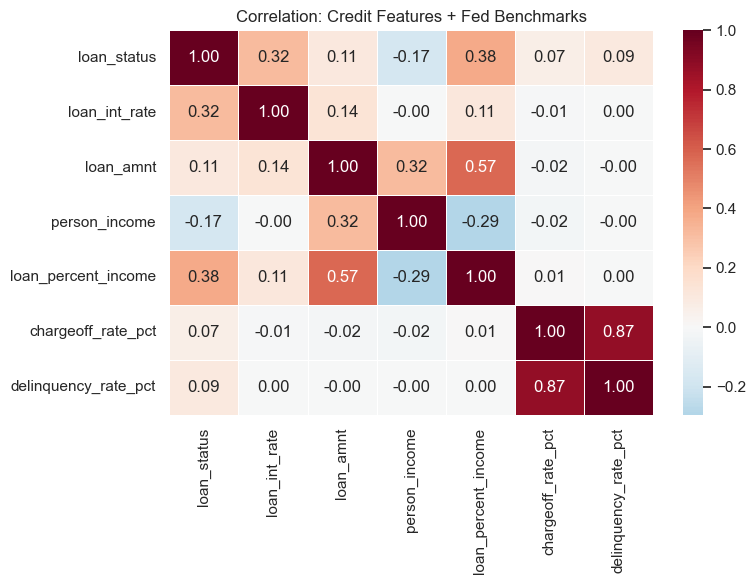

In [29]:
# Full correlation including benchmarks
corr_cols = ["loan_status", "loan_int_rate", "loan_amnt", "person_income",
             "loan_percent_income", "chargeoff_rate_pct", "delinquency_rate_pct"]
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(merged[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation: Credit Features + Fed Benchmarks")
plt.tight_layout()
plt.show()

Summary of the Correlation Heatmap (Credit Features + Fed Benchmarks):

Loan default (loan_status) has the strongest positive relationship with loan_percent_income (0.38) and interest rate (0.32), suggesting borrowers who spend a larger portion of income on loans and pay higher interest are more likely to default.

Loan amount and loan_percent_income (0.57) show a strong positive correlation, meaning larger loans typically consume a bigger share of borrower income.

Person income has a negative correlation with loan_percent_income (-0.29), indicating higher-income borrowers spend a smaller proportion of income on loans.

Fed benchmarks — charge-off rate and delinquency rate (0.87) — are highly correlated with each other but show very weak correlation with individual loan features, implying macro credit conditions move together but do not strongly explain individual borrower behavior.

## 9. Summary

In [30]:
print("Credit dataset:", len(credit), "loans |", f"Default rate: {credit['loan_status'].mean():.2%}")
print()
print(comparison[["loan_intent", "fed_category", "chargeoff_rate_pct",
                   "Credit_default_pct", "gap_vs_chargeoff"]].to_string(index=False))

Credit dataset: 32576 loans | Default rate: 21.82%

      loan_intent fed_category  chargeoff_rate_pct  Credit_default_pct  gap_vs_chargeoff
  HOMEIMPROVEMENT   realestate                0.45               26.10             25.65
          VENTURE   commercial                0.72               14.82             14.10
        EDUCATION     consumer                2.51               17.22             14.71
          MEDICAL     consumer                2.51               26.70             24.19
         PERSONAL     consumer                2.51               19.89             17.38
DEBTCONSOLIDATION   creditcard                4.82               28.59             23.77


The table compares loan default rates observed in the credit dataset with Federal Reserve (Fed) charge-off benchmarks for similar types of loans, helping us understand how realistic or risky the dataset is relative to the broader financial system. The loan_intent column represents the purpose of the loan in the dataset, such as home improvement, venture/business, education, medical, personal, or debt consolidation. The fed_category column maps each loan type to the closest comparable category used in Federal Reserve statistics, such as real estate loans, commercial loans, consumer loans, or credit card loans. The chargeoff_rate_pct column shows the typical percentage of loans that banks charge off as losses according to Fed data, which represents real-world averages across the banking system. In contrast, the Credit_default_pct column shows the percentage of borrowers in this dataset who actually defaulted for each loan purpose.

The gap_vs_chargeoff column measures the difference between the dataset’s default rate and the Fed benchmark. For example, home improvement loans in the dataset show a 26.10% default rate, while the Fed’s comparable real estate charge-off rate is only 0.45%, creating a very large gap of 25.65 percentage points. Similarly, debt consolidation loans have a 28.59% default rate compared with a 4.82% credit card charge-off rate, producing a gap of 23.77 points. Medical loans also show a very high 26.70% default rate versus the Fed’s 2.51% consumer loan loss rate, while personal loans default at 19.89%, far above the same benchmark. Even the smaller gaps, such as venture loans (14.10%) and education loans (14.71%), are still significantly higher than the corresponding Fed averages.

Overall, the comparison shows that every loan category in the dataset has a substantially higher default rate than what is typically observed in the U.S. banking system. This suggests the dataset likely represents a higher-risk lending environment, such as unsecured consumer lending platforms, peer-to-peer lending, or subprime borrowers, rather than traditional bank portfolios. From an analytical perspective, this means the dataset is useful for studying credit risk patterns and default prediction models, but the results should be interpreted carefully because the default rates are much more severe than typical real-world banking averages.